In [1]:
import sys
sys.path.append('../../code/')

In [2]:
%load_ext autoreload
%autoreload 2

from libs import io
from libs import constants
from libs.visuals import vis
from libs.visuals import quadrants
from libs.visuals import trajectories
from libs.visuals import interventions
from libs.metrics import aggregators
from libs.visuals import helpers

Available LLMs: (24): llama-3.1-8b llama-4-scout llama-4-mav gpt-oss-20b gpt-oss-120b qwen3-8b qwen3-14b qwen3-32b qwen3-30b-a3b-2507 qwen3-235b-a22b-2507 gemma-3-12b gemma-3-27b mistral-small-3.2-24b mistral-medium-3 llama-3.1-70b llama-3.3-70b llama-3.1-405b grok-4-fast deepseek-chat-v3.1 deepseek-r1-0528 gemini-2.5-flash gemini-2.5-flash-grounded gemini-2.5-pro gemini-2.5-pro-grounded


/home/espinl/.conda/envs/py311_llmscholar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

In [3]:
BENCHMARKS_PATH = '../../results/interventions/benchmarks/'

PLOTS_PATH = '../../results/interventions/plots'
TABLES_PATH = '../../results/interventions/tables'
LATEX_PATH = '../../results/interventions/latex'

io.validate_path(PLOTS_PATH)
io.validate_path(TABLES_PATH)
io.validate_path(LATEX_PATH)

## Data

In [4]:
PREFIX = 'quadrants'

In [5]:
files = io.get_files(BENCHMARKS_PATH, f'per_attempt_*.csv')
df_per_attempt_all = io.pd.concat([io.read_csv(fn, index_col=0, low_memory=False) for fn in files], ignore_index=True)
df_per_attempt_all.shape

(582560, 15)

# Plots

In [6]:
vis.sns_reset()
vis.sns_paper_style(font_scale=constants.FONT_SCALE)

In [7]:
alpha_ci = 0.05
metric_name_col = 'metric_name'
metric_value_col = 'metric_value'
groupby = ['model', 'metric_name']
cols_order = ['model', 'n','metric_name','mean','std','median','sum','ci','ci_low','ci_high']

parity_cols = [c for c in constants.BENCHMARK_SOCIAL_METRICS if c.startswith('parity')]
diversity_cols = [c for c in constants.BENCHMARK_SOCIAL_METRICS if c.startswith('diversity')]
technical_high_cols = [c for c in constants.BENCHMARK_TECHNICAL_METRICS if c.startswith('validity') or c.startswith('factuality') or c.startswith('duplicates')]


In [8]:
GEMINI_COLORS = {"gemini-2.5-pro": "#1f77b4", "gemini-2.5-flash": "#d62728"}
TRADEOFF_METRICS_LABEL_DISPLAY_MAP = {"duplicates": "duplicates$^{c}$",
                                      "parity": "parity$^{(a)}$", 
                                      "factuality": "factuality$^{(b)}$", 
                                      "validity_pct": "validity",
                                      "factuality_author":"factuality$_{author}$"}
BASELINE_TOP100_STEERED = "baseline_top_100_rag_constrained"
BASELINE_ALL = 'baseline'
INTERVENTIONS_LABEL_MAP = {
                            BASELINE_TOP100_STEERED: "Baseline",
                            "constrained_top_100": "CP",
                            "constrained_rag_top_100": "CP + RAG",
                            "rag_top_100": "RAG",
                        }
STEER_DIVERSITY_TASKS = ['top_100_bias_diverse','top_100_bias_ethnicity_equal','top_100_bias_gender_equal','top_100']

## Social vs. Technical

In [9]:
key_cols = ["model_access", "model_size", "model_class", "model", "grounded", "temperature", "date", "time", "task_name", "task_param", "task_attempt", "n_total", "n_counts"]

# select duplicates rows, and create inverse metric: "uniqueness"
dup = df_per_attempt_all[df_per_attempt_all["metric_name"] == "duplicates"].copy()
dup["metric_value"] = 1.0 - dup["metric_value"]
dup["metric_name"] = "uniqueness"
technical_high_cols.remove("duplicates")
technical_high_cols.append("uniqueness")

# the same for refusals
com = df_per_attempt_all[df_per_attempt_all["metric_name"] == "refusal_pct"].copy()
com["metric_value"] = 1.0 - com["metric_value"]
com["metric_name"] = "compliant_pct"

# append back
df_per_attempt_all_mod = io.pd.concat([df_per_attempt_all, dup], ignore_index=True)
df_per_attempt_all_mod = io.pd.concat([df_per_attempt_all_mod, com], ignore_index=True)
df_per_attempt_all_mod.head(2)

,model_access,model_size,model_class,model,grounded,temperature,date,time,task_name,task_param,task_attempt,n_total,n_counts,metric_name,metric_value
0,open,XL,non-reasoning,llama-3.1-405b,False,1.0,2025-12-19,08:00,biased_top_k,top_100_bias_citations_high,1.0,1.0,0.0,refusal_pct,0.0
1,open,XL,non-reasoning,llama-3.1-405b,False,1.0,2025-12-19,08:00,biased_top_k,top_100_bias_citations_high,2.0,1.0,0.0,refusal_pct,0.0


temperature
../../results/interventions/plots/quadrants_social_vs_technical_temperature.pdf


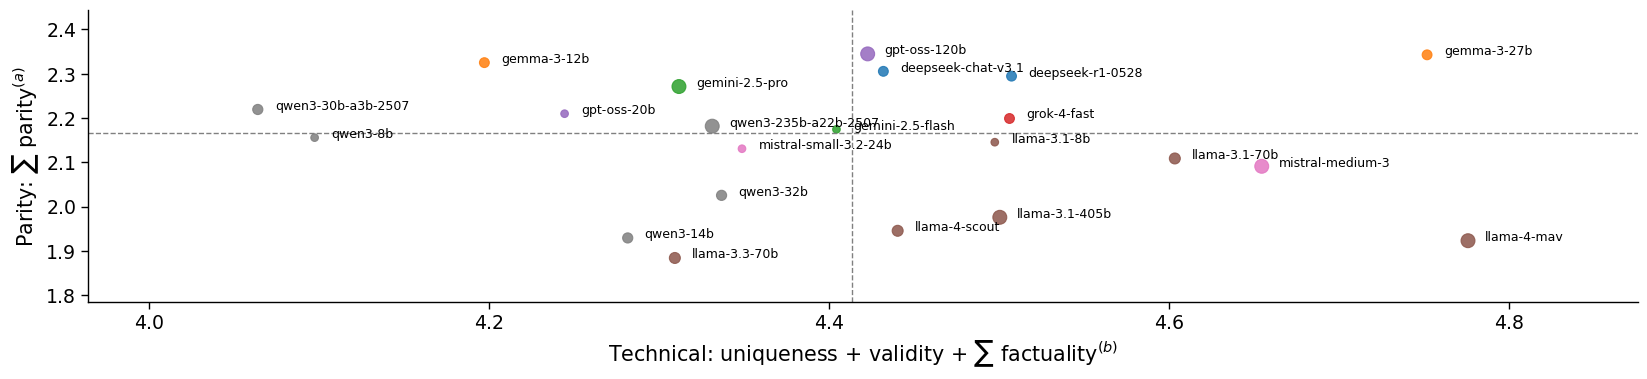

baseline
../../results/interventions/plots/quadrants_social_vs_technical_baseline.pdf


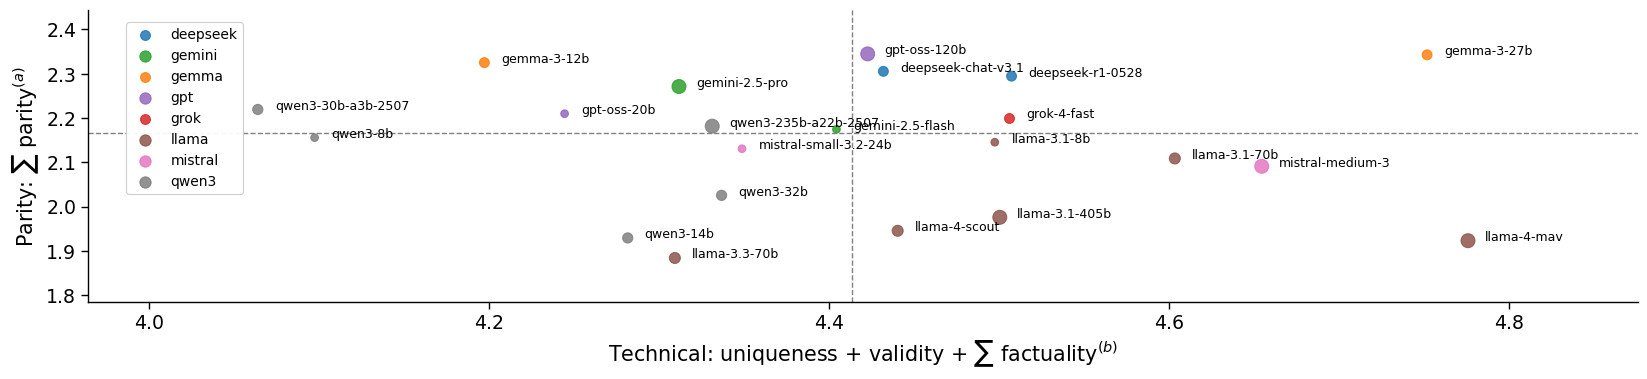

rag
../../results/interventions/plots/quadrants_social_vs_technical_rag.pdf


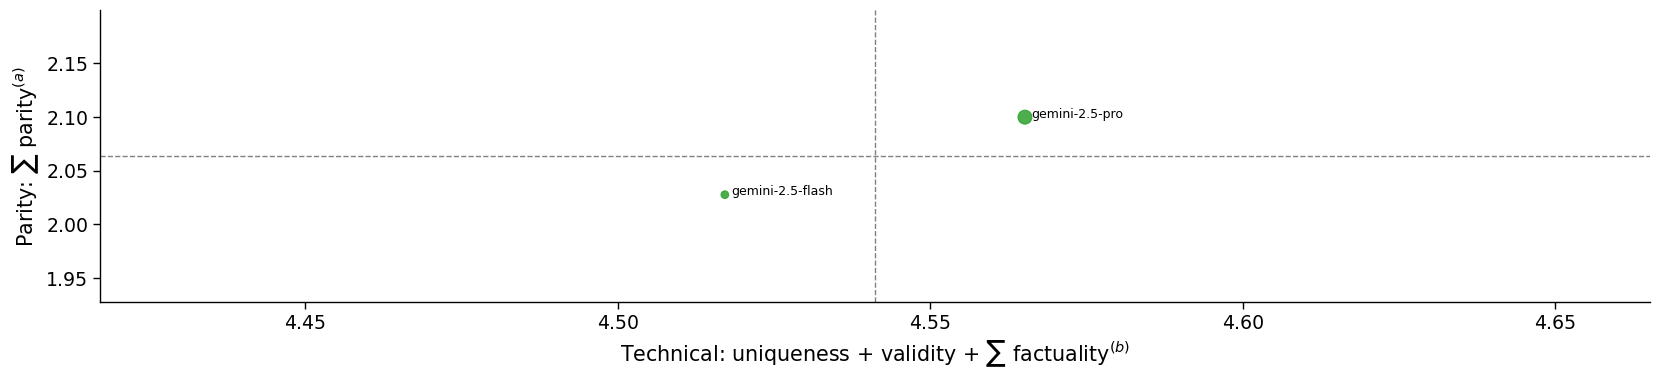

constrained_prompting
../../results/interventions/plots/quadrants_social_vs_technical_constrained_prompting.pdf


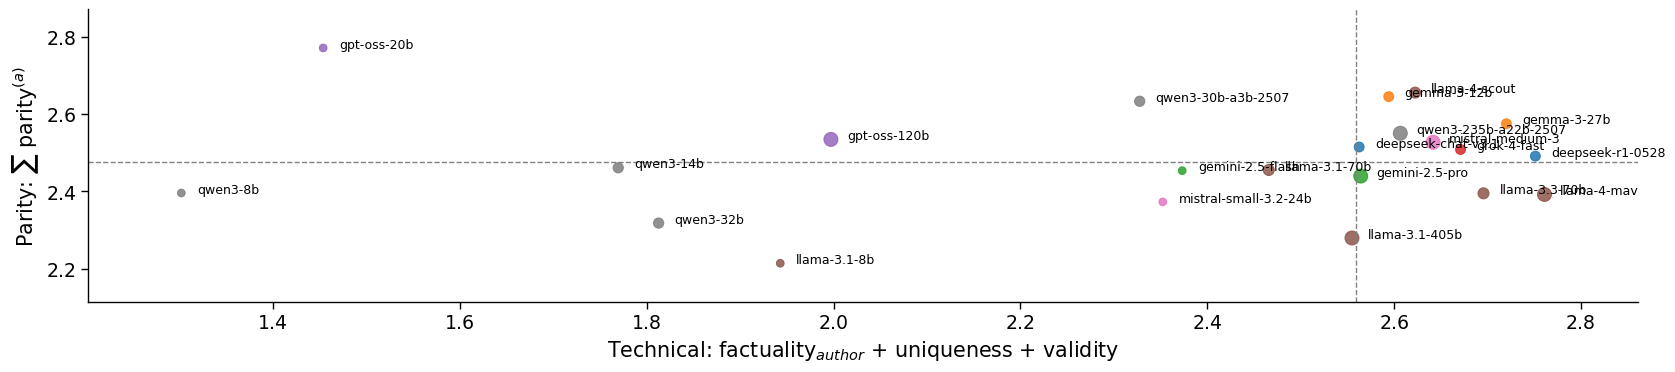

In [10]:
for experiment, query in constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS.items():

    if experiment in ['baseline_top_100', 'baseline_rag'] or experiment in constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI:
        continue

    print(experiment)
    
    #### GROUP DATA #####
    df_per_attempt = df_per_attempt_all_mod.query(query).copy()
    df_per_attempt.loc[:, 'model'] = df_per_attempt.model.apply(lambda x: x.replace('-grounded', ''))

    df_models_ = io.pd.DataFrame()

    df_models_ = aggregators.aggregate_per_group(df_per_attempt, groupby, alpha=alpha_ci, metric_value_col=metric_value_col, metric_name_col=metric_name_col)
    df_models_ = df_models_[cols_order]

    df_models_.loc[:, 'metric_kind_plot'] = df_models_.metric_name.apply(lambda x: 'technical' if x in technical_high_cols else 'parity' if x in parity_cols else 'other')

    df_models = df_models_.groupby(['model','metric_kind_plot'])['mean'].sum().reset_index()

    df_models = df_models.pivot(index='model', columns='metric_kind_plot', values='mean').reset_index()
    df_models.loc[:, 'family'] = df_models.model.apply(lambda x: x.split('-')[0])
    df_models = df_models.merge(df_per_attempt[['model', 'model_size']].drop_duplicates(), on='model', how='left')
    df_models.loc[:, 'size'] = df_models.model_size.apply(lambda x: 5 if x == 'S' else 20 if x == 'M' else 50 if x == 'L' else 100)



    ###### PLOT ######
    metrics_per_axis = df_models_.groupby('metric_kind_plot').metric_name.unique()
    x = 'technical'
    y = 'parity'

    spec = quadrants.SpaceSpec(
        x="technical",
        y="parity",
        id_col="model",
        hue="family",
        hue_colors=constants.LLM_CLASS_COLORS,
        size='size',
        legend_bbox_to_anchor=(0.5, 1.2),
        x_thr_mode='median',
        y_thr_mode='median',
        figsize=(20, 3.8),
        annotation_pad = 0.01 if experiment in ['baseline', 'temperature'] else 0.017 if experiment == 'constrained_prompting' else 0.001, #-0.016
        legend_kwargs=dict(
                        loc="upper left",
                        bbox_to_anchor=(0.02, 0.98),
                        frameon=True,
                        framealpha=0.95,
                        fontsize=10,
                    )
    )

    fig, ax, quad_counts = quadrants.plot_quality_social_space(
        df_models,
        spec=spec,
        title=None,
        density="",           
        jitter=0.,             
        label_points=True,
        label_kwargs={"fontsize": 9},
        marker_size=50,
        show_quadrant_counts=False,
        legend = experiment == BASELINE_ALL,
        xlabel = helpers.build_axis_label(x,metrics_per_axis[x],display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP),
        ylabel = helpers.build_axis_label(y,metrics_per_axis[y],display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP),
    )

    # xlim_min, xlim_max = 1.2, 4.9
    # ylim_min, ylim_max = 1.85, 2.8
    
    smooth = 0.1
    ax.set_xlim(df_models.technical.min()-smooth, df_models.technical.max()+smooth)
    ax.set_ylim(df_models.parity.min()-smooth, df_models.parity.max()+smooth)

    fn = io.path_join(PLOTS_PATH, f"{PREFIX}_social_vs_technical_{experiment}.pdf")
    if fn is not None:
        fig.savefig(fn, bbox_inches="tight", dpi=constants.FIG_DPI)
        print(fn)


    quadrants.plt.show()
    quadrants.plt.close()


## Only top 100 (steered diversity & Gemini)

In [11]:
df_per_attempt_all_mod_steer = df_per_attempt_all_mod.query("task_param in @STEER_DIVERSITY_TASKS").copy()
df_per_attempt_all_mod_steer.shape

(92750, 15)

### Trade-off

baseline_top_100_rag_constrained
../../results/interventions/plots/quadrants_social_vs_technical_baseline_top_100_rag_constrained_top_100.pdf


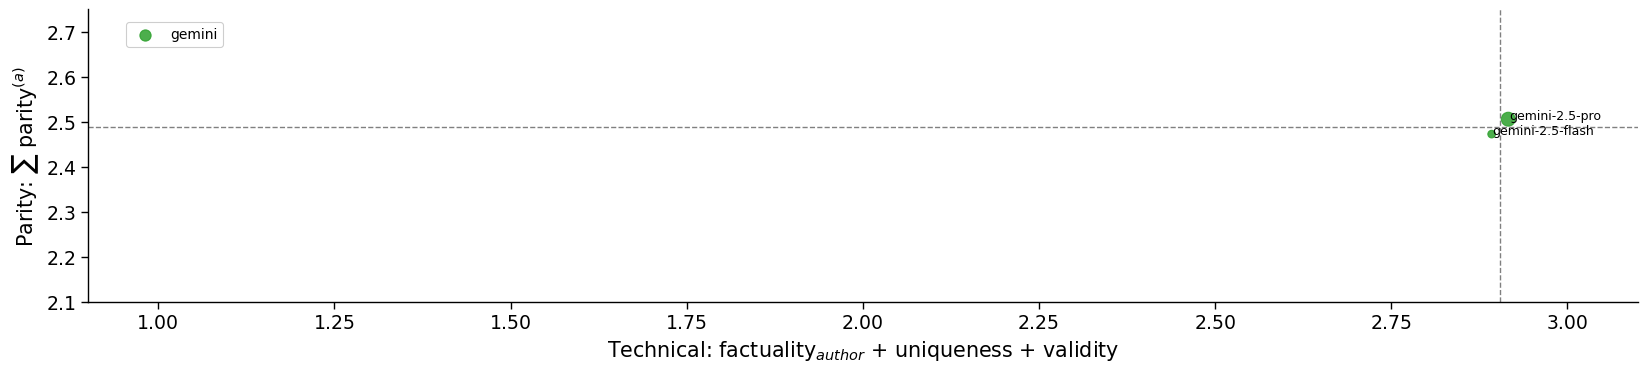

rag_top_100
../../results/interventions/plots/quadrants_social_vs_technical_rag_top_100_top_100.pdf


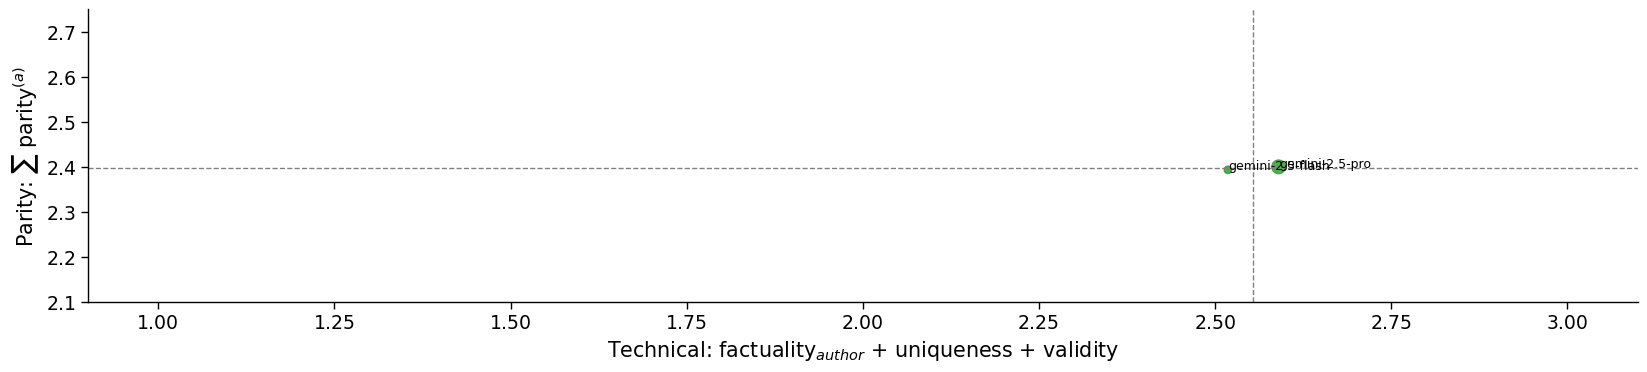

constrained_top_100
../../results/interventions/plots/quadrants_social_vs_technical_constrained_top_100_top_100.pdf


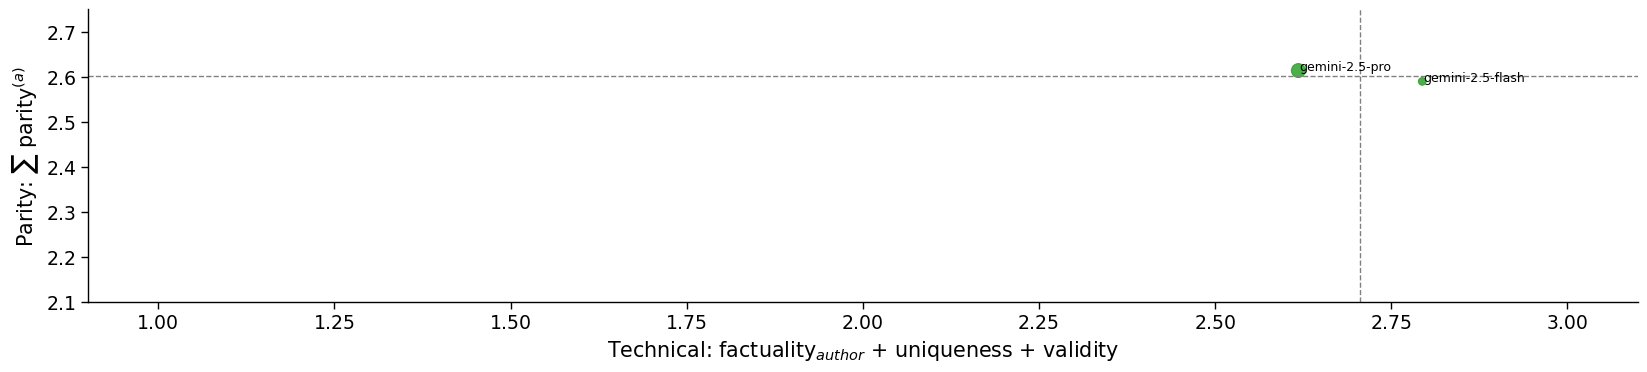

constrained_rag_top_100
../../results/interventions/plots/quadrants_social_vs_technical_constrained_rag_top_100_top_100.pdf


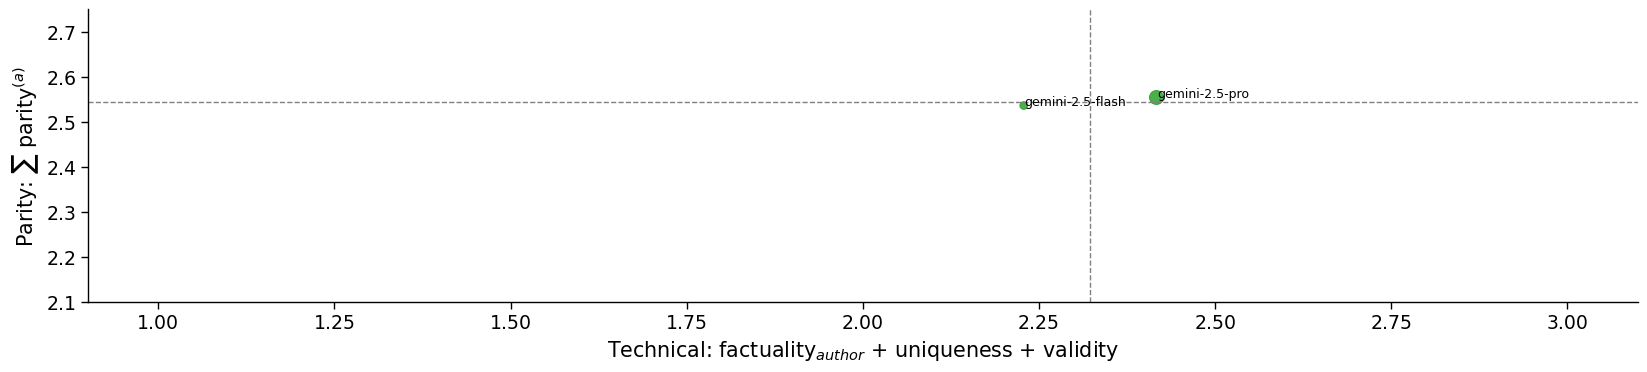

In [12]:
for experiment, query in constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI.items():

    # if experiment in ['baseline_top_100', 'baseline_rag'] or experiment in constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI:
        # continue

    print(experiment)

    #### GROUP DATA #####
    df_per_attempt = df_per_attempt_all_mod_steer.query(query).copy()
    # df_per_attempt = df_per_attempt.query("task_param == 'top_100' or task_name == 'biased_top_k'")
    df_per_attempt.loc[:, 'model'] = df_per_attempt.model.apply(lambda x: x.replace('-grounded', ''))

    df_models_ = io.pd.DataFrame()

    df_models_ = aggregators.aggregate_per_group(df_per_attempt, groupby, alpha=alpha_ci, metric_value_col=metric_value_col, metric_name_col=metric_name_col)
    df_models_ = df_models_[cols_order]

    # df_models_.loc[:, 'metric_kind'] = df_models.metric_name.apply(lambda x: 'technical' if x in constants.BENCHMARK_TECHNICAL_METRICS + ['uniqueness'] else 'social')

    df_models_.loc[:, 'metric_kind_plot'] = df_models_.metric_name.apply(lambda x: 'technical' if x in technical_high_cols else 'parity' if x in parity_cols else 'other')

    df_models = df_models_.groupby(['model','metric_kind_plot'])['mean'].sum().reset_index()

    df_models = df_models.pivot(index='model', columns='metric_kind_plot', values='mean').reset_index()
    df_models.loc[:, 'family'] = df_models.model.apply(lambda x: x.split('-')[0])
    df_models = df_models.merge(df_per_attempt[['model', 'model_size']].drop_duplicates(), on='model', how='left')
    df_models.loc[:, 'size'] = df_models.model_size.apply(lambda x: 5 if x == 'S' else 20 if x == 'M' else 50 if x == 'L' else 100)

    ###### PLOT ######
    metrics_per_axis = df_models_.groupby('metric_kind_plot').metric_name.unique()
    x = 'technical'
    y = 'parity'

    spec = quadrants.SpaceSpec(
        x=x,
        y=y,
        id_col="model",
        hue="family",
        hue_colors=constants.LLM_CLASS_COLORS,
        size='size',
        legend_bbox_to_anchor=(0.5, 1.2),
        x_thr_mode='median',
        y_thr_mode='median',
        figsize=(20, 3.8),
        annotation_pad = 0.01 if experiment in ['baseline', 'temperature'] else 0.017 if experiment == 'constrained_prompting' else 0.001, #-0.016
        legend_kwargs=dict(
                        loc="upper left",
                        bbox_to_anchor=(0.02, 0.98),
                        frameon=True,
                        framealpha=0.95,
                        fontsize=10,
                    ),
    )

    fig, ax, quad_counts = quadrants.plot_quality_social_space(
        df_models,
        spec=spec,
        title=None,
        density="",           
        jitter=0.,             
        label_points=True,
        label_kwargs={"fontsize": 9},
        marker_size=50,
        show_quadrant_counts=False,
        legend = experiment == BASELINE_TOP100_STEERED,

        xlabel = helpers.build_axis_label(x,metrics_per_axis[x], display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP),
        ylabel = helpers.build_axis_label(y,metrics_per_axis[y], display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP),
    )

    xlim_min, xlim_max = 0.9, 3.1
    ylim_min, ylim_max = 2.1, 2.75

    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)    
    
    fn = io.path_join(PLOTS_PATH, f"{PREFIX}_social_vs_technical_{experiment}_top_100.pdf")
    print(fn)
    if fn is not None:
        fig.savefig(fn, bbox_inches="tight", dpi=constants.FIG_DPI)


    quadrants.plt.show()
    quadrants.plt.close()


### Trajectories

Plotting trajectory for gemini-2.5-pro...
Saved trajectory plot for gemini-2.5-pro to ../../results/interventions/plots/quadrants_social_vs_technical_gemini-2.5-pro_trajectory.pdf


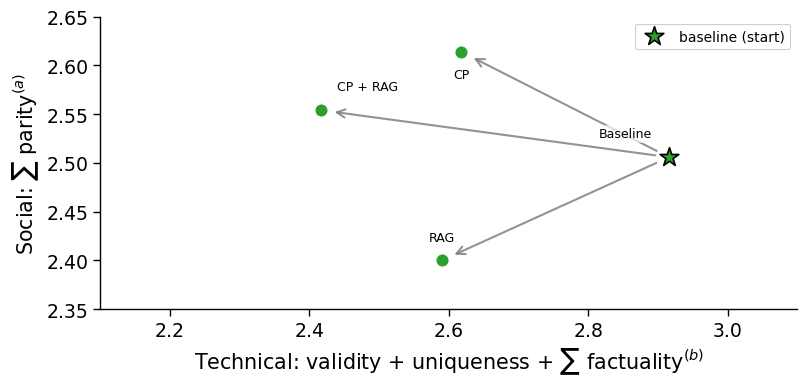

Plotting trajectory for gemini-2.5-flash...
Saved trajectory plot for gemini-2.5-flash to ../../results/interventions/plots/quadrants_social_vs_technical_gemini-2.5-flash_trajectory.pdf


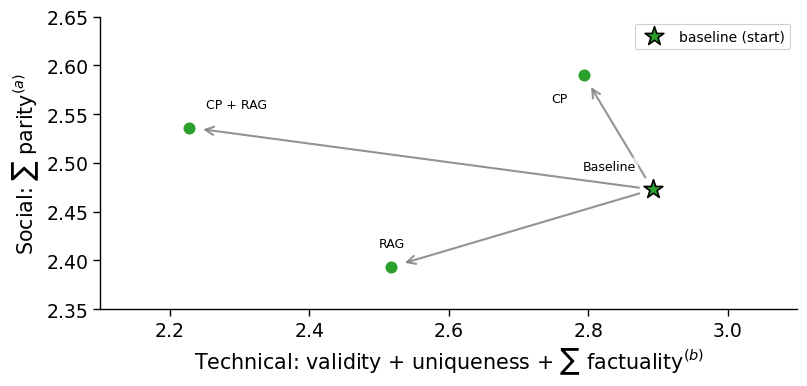

In [13]:
social_group = 'parity'
social_cols = parity_cols if social_group == 'parity' else diversity_cols

for model in set([c.replace('-grounded', '') for c in constants.LLMS_GEMINI]):
    
    print(f"Plotting trajectory for {model}...")
    traj = helpers.build_model_trajectory(
        df_per_attempt_all_mod_steer,
        model,
        constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI,
        baseline_experiment=BASELINE_TOP100_STEERED,
        aggregate_fn=aggregators.aggregate_per_group,
        groupby=groupby,
        alpha_ci=alpha_ci,
        metric_value_col=metric_value_col,
        metric_name_col=metric_name_col,
        cols_order=cols_order,
        technical_cols=technical_high_cols,
        social_cols=social_cols,
        query_env={"constants": constants},
    )
    fig, ax = trajectories.plot_model_trajectory(
        traj,
        model,
        color=constants.LLM_CLASS_COLORS.get(model.split("-")[0]),
        connect="from_baseline",   # or "from_baseline" or "sequential"
        label_map=INTERVENTIONS_LABEL_MAP,
        use_adjust_text=False,  # set True if labels still collide
        figsize=(9, 3.8),
        technical_cols=technical_high_cols,   # e.g. ["validity","duplicates","factuality_b1",...]
        social_cols=social_cols,              # e.g. ["parity_author","parity_field",...]
        label_display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP,
    )

    ax.set_ylim((2.35, 2.65))
    ax.set_xlim((2.1, 3.1))

    fn = io.path_join(PLOTS_PATH, f"{PREFIX}_social_vs_technical_{model}_trajectory.pdf")
    if fn is not None:
        fig.savefig(fn, bbox_inches="tight", dpi=constants.FIG_DPI)   
        print(f"Saved trajectory plot for {model} to {fn}")
        
    trajectories.plt.show()
    trajectories.plt.close()

Saved trajectory plot to ../../results/interventions/plots/quadrants_social:parity_vs_technical_trajectories.pdf


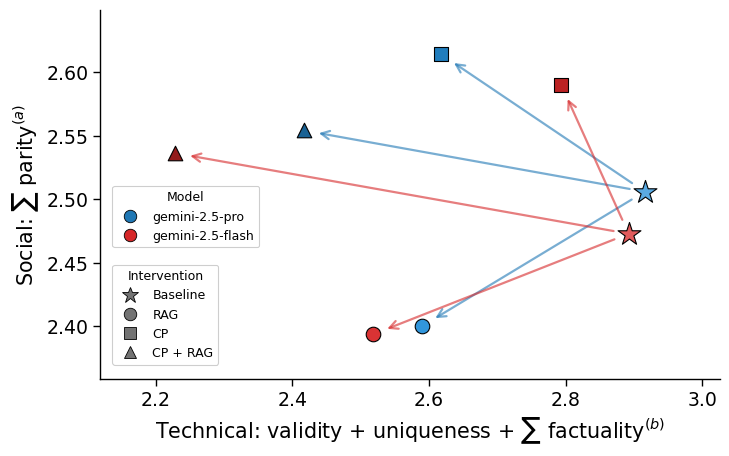

In [14]:
models = set([c.replace('-grounded', '') for c in constants.LLMS_GEMINI])

social_group = 'parity'
social_cols = parity_cols if social_group == 'parity' else diversity_cols

agg_kwargs = dict(
    baseline_experiment=BASELINE_TOP100_STEERED,
    aggregate_fn=aggregators.aggregate_per_group,
    groupby=groupby, alpha_ci=alpha_ci,
    metric_value_col=metric_value_col, metric_name_col=metric_name_col,
    cols_order=cols_order, 
    technical_cols=technical_high_cols,
    social_cols=social_cols, 
    query_env={"constants": constants},
)
trajectories_dict = {
    m: helpers.build_model_trajectory(
        df_per_attempt_all_mod_steer, m,
        constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI, **agg_kwargs,
    )
    for m in models
}
fig, ax = trajectories.plot_models_trajectories(
    trajectories_dict,
    model_colors=GEMINI_COLORS,  # distinct hues
    label_map=INTERVENTIONS_LABEL_MAP,
    
    # intervention_markers={"baseline_top_100_rag_constrained": "*", "constrained_top_100": "o", ...},
    label_mode="none",   # markers + legend carry intervention; "per_point" to add text too
    figsize=(8, 4.8),
    connect="from_baseline",   # or "from_baseline" or "sequential"
    
    technical_cols=technical_high_cols,   # e.g. ["validity","duplicates","factuality_b1",...]
    social_cols=social_cols,              # e.g. ["parity_author","parity_field",...]
    label_display=TRADEOFF_METRICS_LABEL_DISPLAY_MAP,

    legend_anchor=(0.01, 0.54)
)

ax._legend = None

fn = io.path_join(PLOTS_PATH, f"{PREFIX}_social:parity_vs_technical_trajectories.pdf")
if fn is not None:
    fig.savefig(fn, bbox_inches="tight", dpi=constants.FIG_DPI)   
    print(f"Saved trajectory plot to {fn}")

vis.plt.show()
vis.plt.close()

### Differences

File save path: ../../results/interventions/plots/top_100_gemini_intervention_effects.pdf


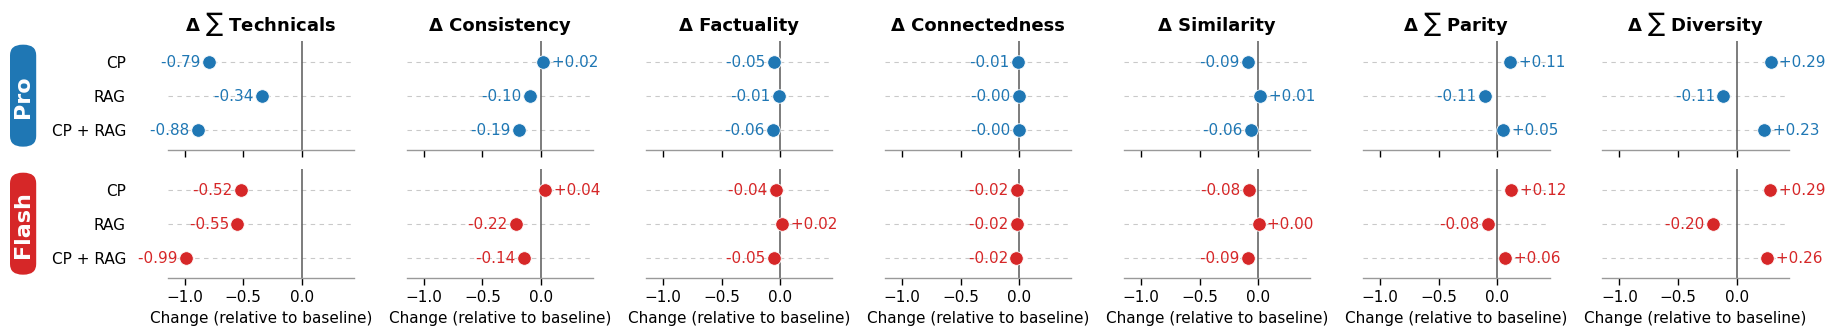

In [15]:
vis.sns_paper_style(font_scale=1.8)
models = set([c.replace('-grounded', '') for c in constants.LLMS_GEMINI])

# shared builder args (your real project objects)
build_kwargs = dict(
    aggregate_fn=aggregators.aggregate_per_group,
    metric_value_col=metric_value_col,
    metric_name_col=metric_name_col,
    technical_cols=constants.BENCHMARK_TECHNICAL_METRICS + ['uniqueness', 'compliant_pct'],  
    social_cols=constants.BENCHMARK_SOCIAL_METRICS,              
    alpha_ci=alpha_ci,
    baseline_experiment=BASELINE_TOP100_STEERED,       
    query_env={"constants": constants},   
)

# 1) per-metric trajectory per model  ->  wide df: [experiment, <metric...>, is_baseline]
trajectories_metrics_dict = {
    m: helpers.build_metric_trajectory(
        df_per_attempt_all_mod_steer, m,
        constants.EXPERIMENT_TYPE_QUERY_TO_FILTER_RECORDS_GEMINI,
        **build_kwargs,
    )
    for m in models
}

# 2) one panel per individual metric (column -> display title)
titles = {
    "technical_high": "Δ $\sum$ Technicals", # (validity + refusals$^c$ + duplicates$^c$)",
    "consistency": "Δ Consistency",
    "factuality_author": "Δ Factuality",

    "connectedness": "Δ Connectedness",
    "similarity_pca": "Δ Similarity",

    "parity": "Δ $\sum$ Parity", 
    "diversity": "Δ $\sum$ Diversity",
}
specs = [interventions.MetricSpec(c, titles.get(c, f"Δ {c}")) for c in titles]

fn = io.path_join(PLOTS_PATH, f"top_100_gemini_intervention_effects.pdf")
print(f"File save path: {fn}")

# 3) compute deltas + draw
fig = interventions.plot_intervention_effects(
    trajectories_metrics_dict,  
    metrics=specs,
    label_map=INTERVENTIONS_LABEL_MAP,
    model_grouping_kind="ylabel",
    model_map=constants.LLM_GEMINI_VERSION_LABEL_MAPPING,
    intervention_order=["CP", "RAG", "CP + RAG"],
    model_colors=GEMINI_COLORS, 
    panel_width=1.6,  
    panel_height=1.1,
    save_path=fn,     
)
vis.sns_reset()